In [193]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

import activation, loss, layer, model
importlib.reload(activation)
importlib.reload(loss)
importlib.reload(layer)
importlib.reload(model)

from activation import Linear, ReLU, Sigmoid, Tanh, Softmax
from loss import BinaryCrossEntropy
from layer import DenseLayer
from model import Neural_Network

In [194]:
def preprocess_data(file_path):
    df = pd.read_csv(file_path)
    
    X = df.drop(columns=['placement_status'])
    y = df['placement_status']
    
    categorical_cols = X.select_dtypes(include=['object']).columns
    X = pd.get_dummies(X, columns=categorical_cols)
    
    scaler = StandardScaler()
    numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns
    X[numerical_cols] = scaler.fit_transform(X[numerical_cols])
    X = X.astype(np.float64)
    
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y).astype(np.float64)
    y_binary = y_encoded.reshape(-1, 1)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X.to_numpy(dtype=np.float64),
        y_binary,
        test_size=0.2,
        random_state=42,
        stratify=y_encoded
    )
    
    return X_train, X_test, y_train, y_test, label_encoder

X_train, X_test, y_train, y_test, label_encoder = preprocess_data('datasetml_2026.csv')
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

X_train: (8000, 28), X_test: (2000, 28)


In [195]:
def build_network(layers, activations, init_method='uniform', init_params=None, **kwargs):
    if init_params is None: init_params = {'low': -0.3, 'high': 0.3}
    network = Neural_Network()
    
    for i in range(len(layers) - 1):
        act = activations[i] if i < len(activations) else Sigmoid()
        network.add(DenseLayer(layers[i], layers[i+1], act, init_method, init_params, **kwargs))
    return network

def run_experiment(name, model, epochs=40, lr=0.01, batch_size=32, verbose=0, **kwargs):
    print(f"Running {name}...")
    history = model.train(X_train, y_train, loss=BinaryCrossEntropy(), 
                          epochs=epochs, learning_rate=lr, batch_size=batch_size, 
                          x_val=X_test, y_val=y_test, verbose=verbose)
    
    # Evaluasi
    y_prob = model.predict(X_test).reshape(-1)
    y_pred = (y_prob >= 0.5).astype(int)
    y_true = y_test.reshape(-1).astype(int)

    metrics = {
        'experiment': name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'final_train_loss': history['train_loss'][-1],
        'final_val_loss': history['val_loss'][-1] if history['val_loss'] else np.nan,
        **kwargs 
    }
    
    return {'model': model, 'history': history, 'metrics': metrics, 'prob': y_prob, 'pred': y_pred}

def plot_history_collection(results, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for name, res in results.items():
        axes[0].plot(res['history']['train_loss'], label=name)
        axes[1].plot(res['history']['val_loss'], label=name)
    
    for ax, t in zip(axes, ['Training Loss', 'Validation Loss']):
        ax.set_title(f"{title} - {t}"); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
        ax.grid(alpha=0.3); ax.legend()
    plt.tight_layout(); plt.show()

def results_to_dataframe(results):
    df = pd.DataFrame([res['metrics'] for res in results.values()])
    return df.sort_values(by='accuracy', ascending=False).reset_index(drop=True)

def show_distributions(results, names=None):
    """Plot distribusi bobot dan gradien untuk keperluan analisis spek."""
    target_names = names if names else results.keys()
    for name in target_names:
        print(f"--- Distribusi: {name} ---")
        results[name]['model'].plot_weight_distribution()
        results[name]['model'].plot_gradient_distribution()

group_results = {}
summary_tables = {}

Running Width_8...
Running Width_32...
Running Width_128...


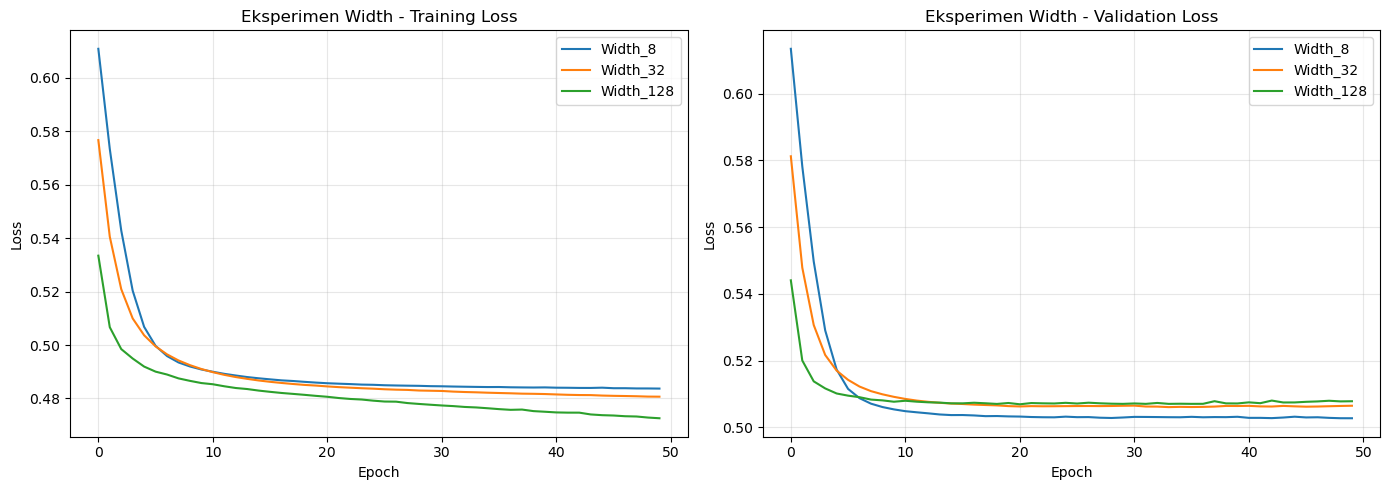

,experiment,accuracy,precision,recall,f1,final_train_loss,final_val_loss,width
0,Width_8,0.7525,0.776692,0.839155,0.806716,0.483698,0.502720,8
1,Width_32,0.7515,0.781011,0.828595,0.804099,0.480663,0.506469,32
2,Width_128,0.7505,0.773134,0.841592,0.805912,0.472589,0.507821,128


In [196]:
width_results = {}
widths = [8, 32, 128]

for w in widths:
    name = f"Width_{w}"
    
    model = build_network([X_train.shape[1], w, 1], activations=[ReLU()])
    
    width_results[name] = run_experiment(name, model, epochs=50, lr=0.01, width=w)

plot_history_collection(width_results, "Eksperimen Width")
display(results_to_dataframe(width_results))

Running Depth_1...
Running Depth_3...
Running Depth_5...


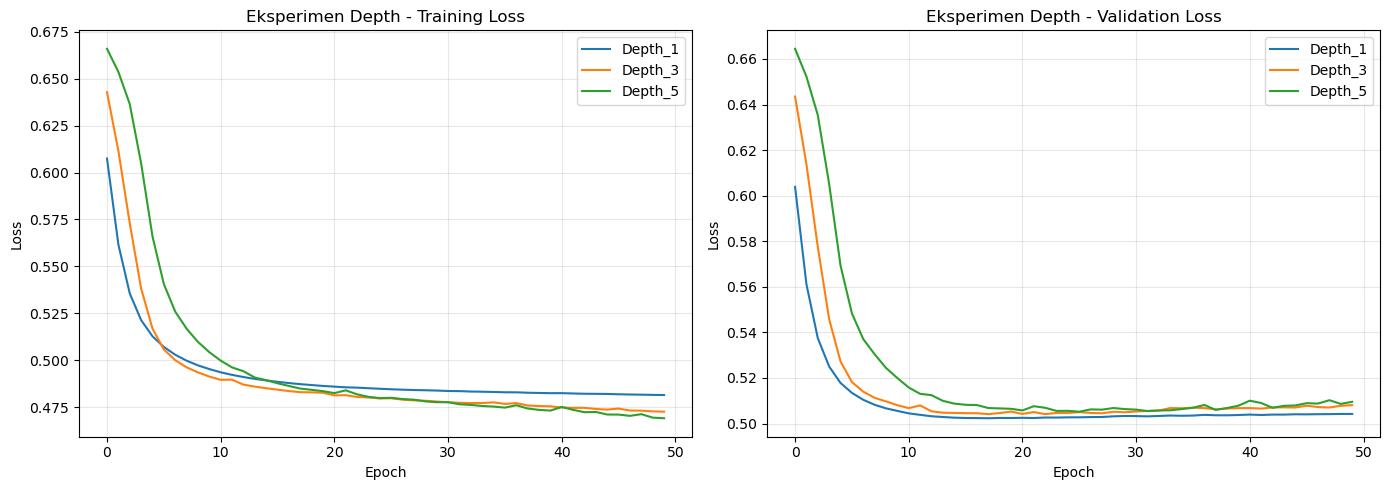

,experiment,accuracy,precision,recall,f1,final_train_loss,final_val_loss,depth
0,Depth_1,0.755,0.780045,0.838343,0.808144,0.481559,0.504208,1
1,Depth_3,0.751,0.774944,0.839155,0.805772,0.472675,0.508076,3
2,Depth_5,0.749,0.776346,0.831844,0.803137,0.469182,0.509522,5


In [197]:
depth_results = {}
depths = [1, 3, 5]

for d in depths:
    name = f"Depth_{d}"
    layers = [X_train.shape[1]] + [32] * d + [1]
    activations = [ReLU()] * d
    
    model = build_network(layers, activations)
    
    depth_results[name] = run_experiment(name, model, epochs=50, lr=0.01, depth=d)

plot_history_collection(depth_results, "Eksperimen Depth")
display(results_to_dataframe(depth_results))

Running Activation_ReLU...
Running Activation_Sigmoid...
Running Activation_Tanh...
Running Activation_Linear...


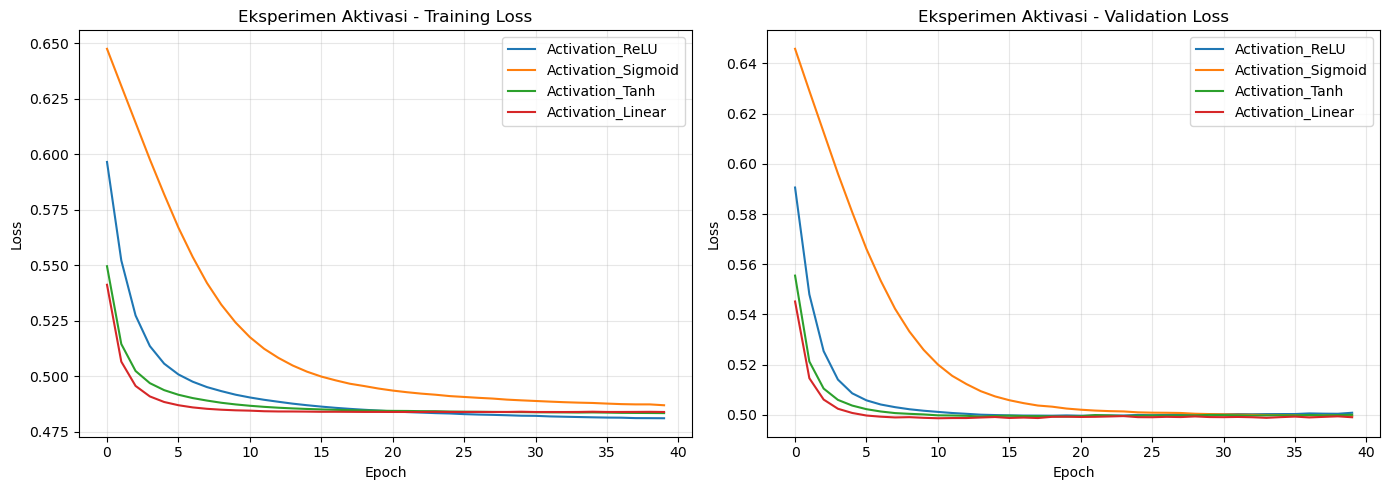

,experiment,accuracy,precision,recall,f1,final_train_loss,final_val_loss,test_activation
0,Activation_Tanh,0.7580,0.781887,0.841592,0.810642,0.483488,0.500013,Tanh
1,Activation_Sigmoid,0.7565,0.780967,0.839968,0.809393,0.487020,0.499604,Sigmoid
2,Activation_ReLU,0.7560,0.784239,0.832656,0.807723,0.481170,0.500809,ReLU
3,Activation_Linear,0.7535,0.775373,0.844029,0.808246,0.483994,0.499015,Linear


--- Distribusi: Activation_ReLU ---


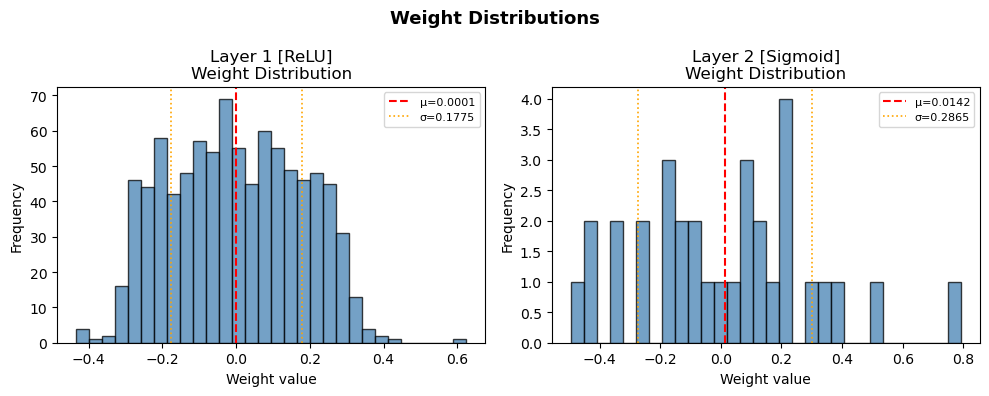

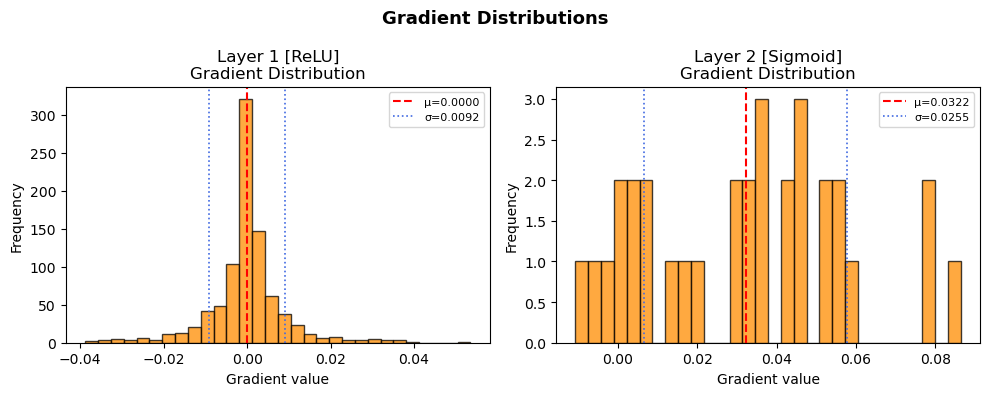

--- Distribusi: Activation_Sigmoid ---


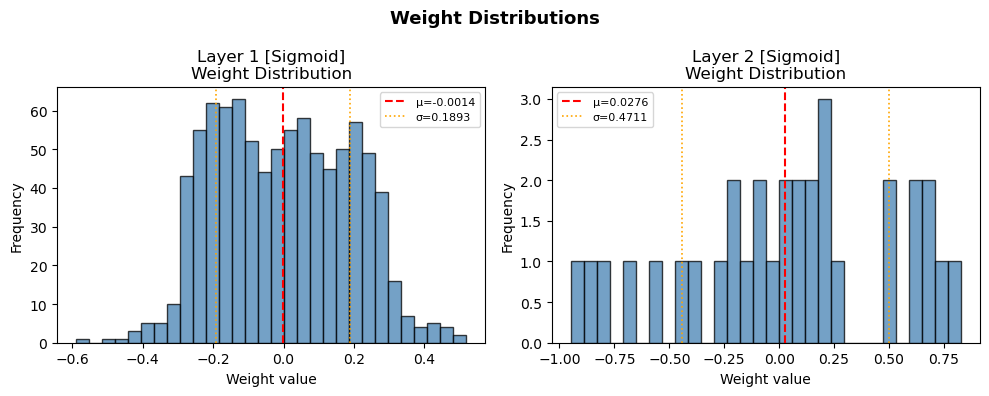

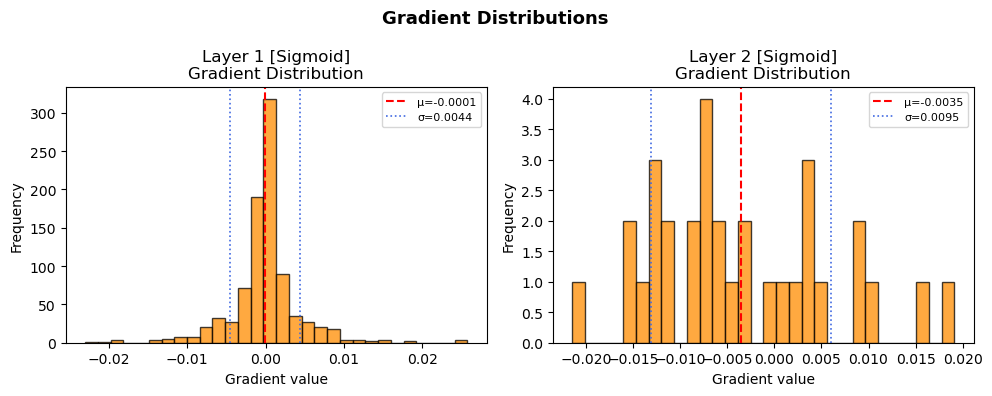

--- Distribusi: Activation_Tanh ---


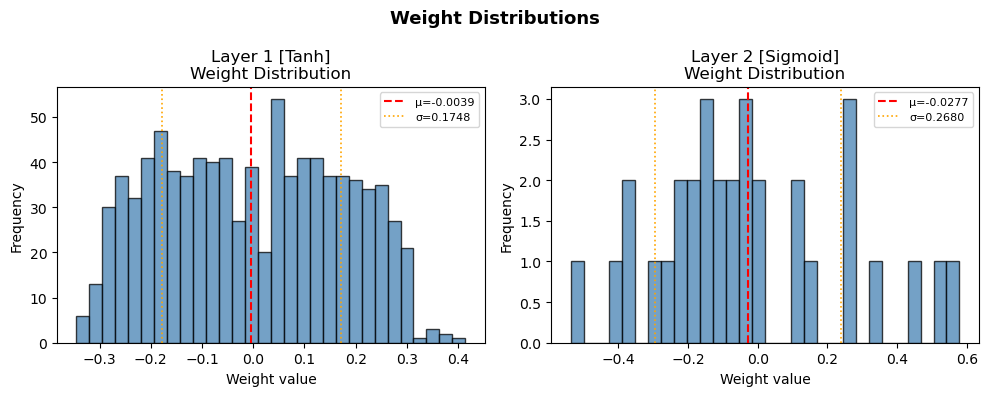

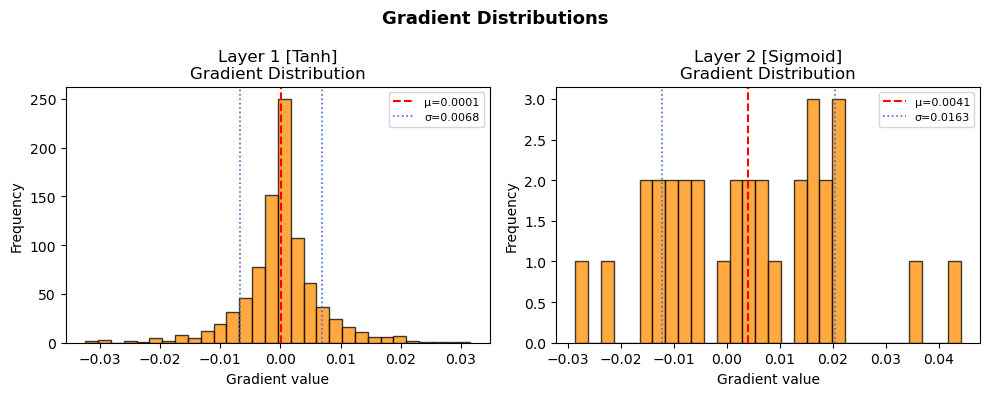

--- Distribusi: Activation_Linear ---


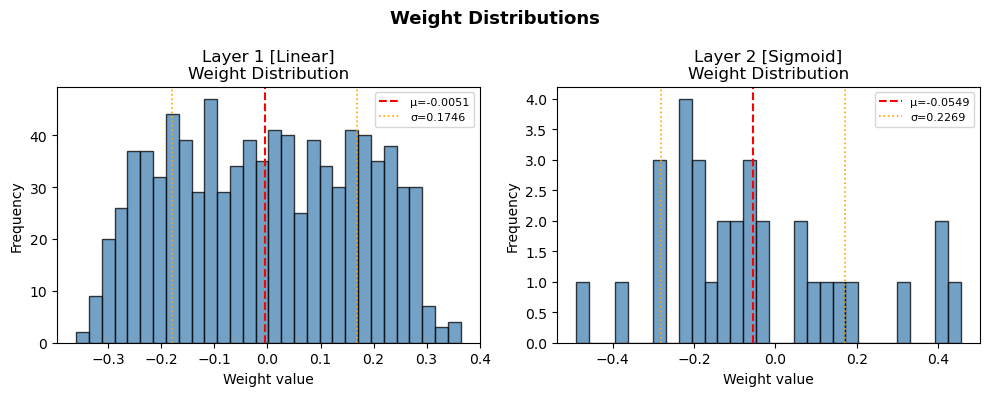

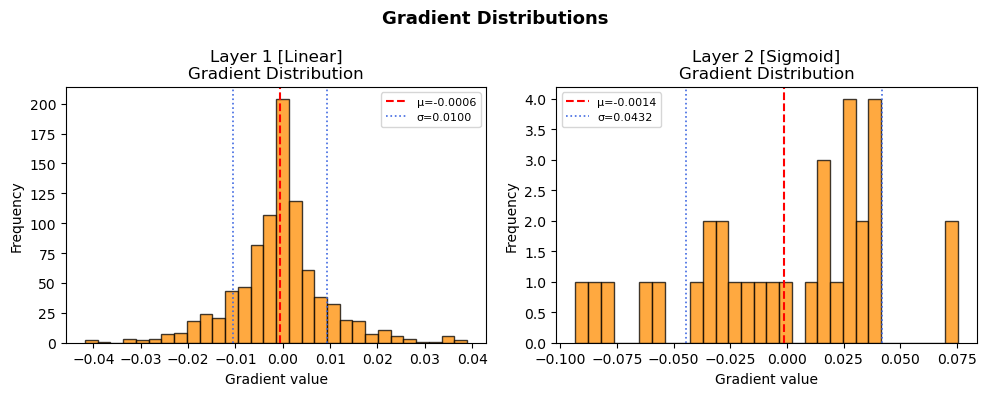

In [198]:
act_results = {}
options = {"ReLU": ReLU(), "Sigmoid": Sigmoid(), "Tanh": Tanh(), "Linear": Linear()}

for act_name, act_obj in options.items():
    name = f"Activation_{act_name}"
    
    model = build_network([X_train.shape[1], 32, 1], activations=[act_obj])
    
    act_results[name] = run_experiment(name, model, test_activation=act_name)

plot_history_collection(act_results, "Eksperimen Aktivasi")
display(results_to_dataframe(act_results))
show_distributions(act_results)

Running LR_0.1...
Running LR_0.01...
Running LR_0.001...


,experiment,accuracy,precision,recall,f1,final_train_loss,final_val_loss,learning_rate
0,LR_0.01,0.753,0.777694,0.838343,0.806880,0.478757,0.502451,0.010
1,LR_0.001,0.747,0.769117,0.841592,0.803724,0.509474,0.522156,0.001
2,LR_0.1,0.742,0.776917,0.814785,0.795400,0.450262,0.522396,0.100


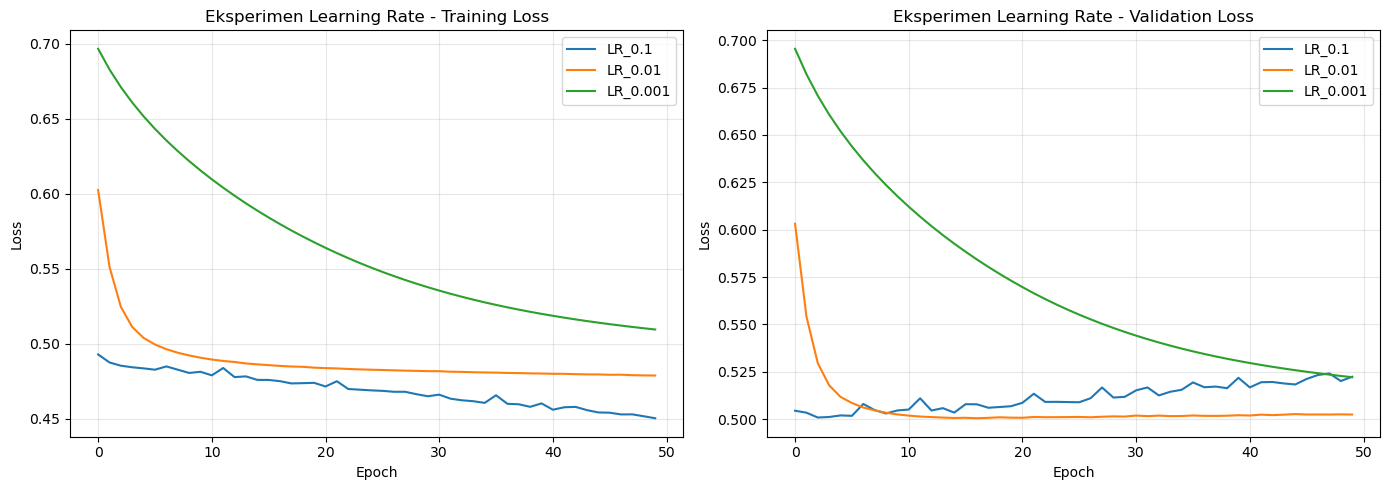

--- Distribusi: LR_0.1 ---


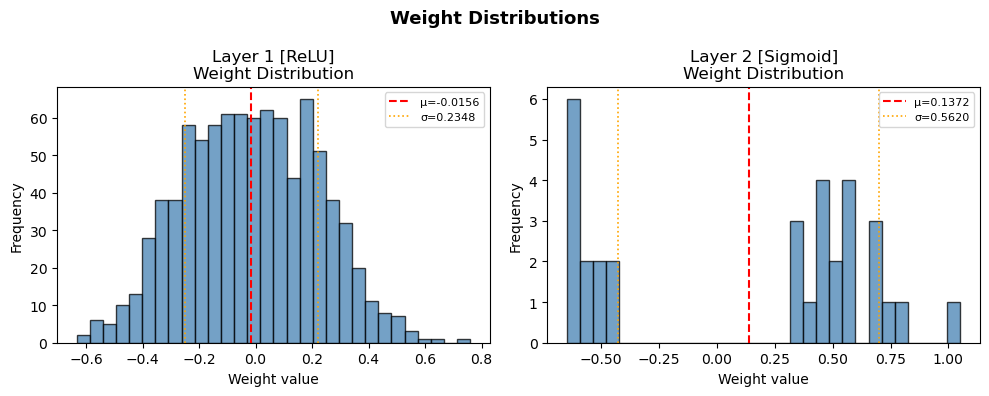

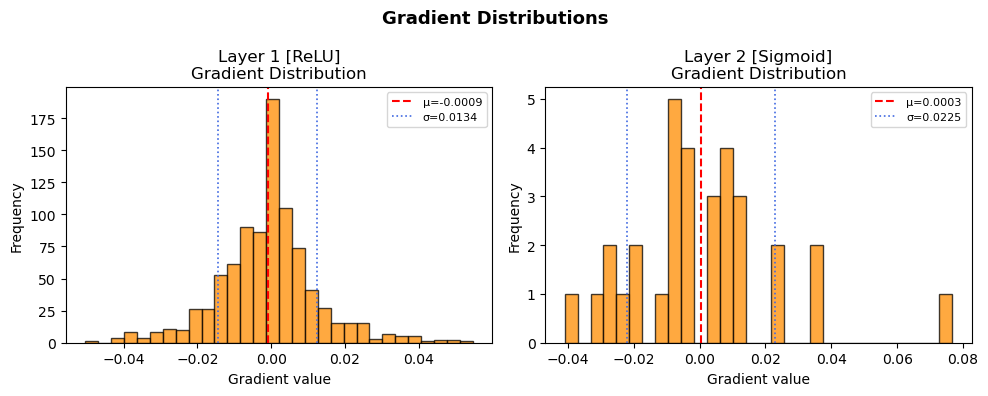

--- Distribusi: LR_0.001 ---


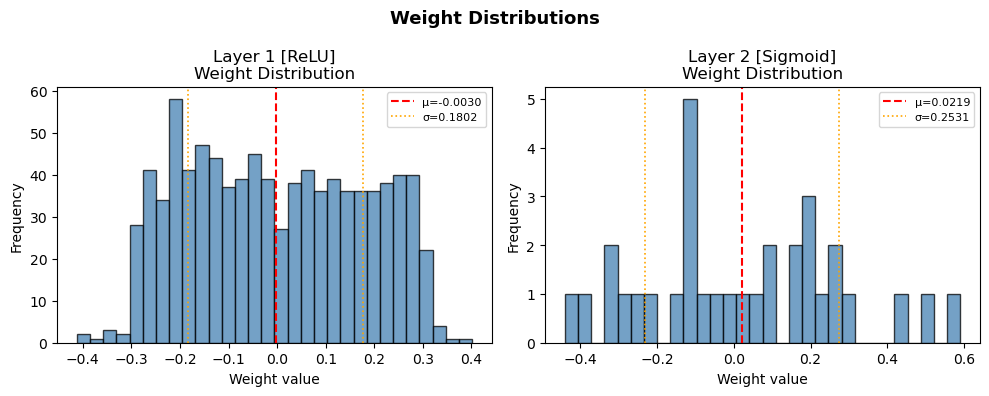

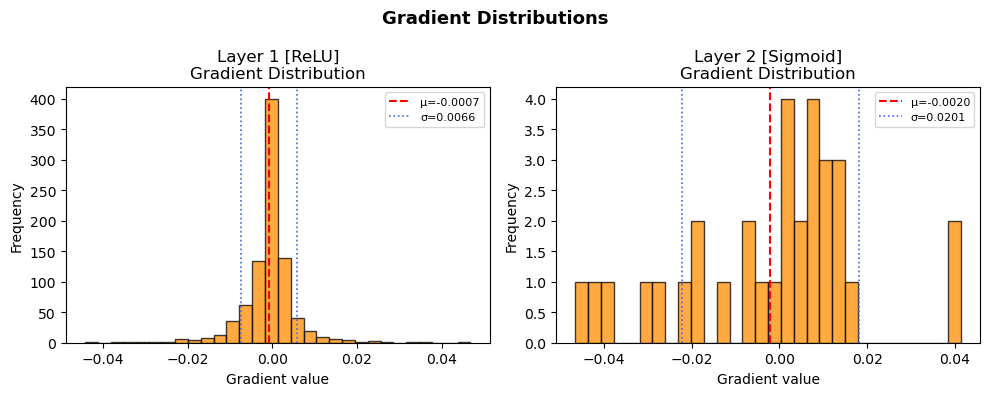

In [199]:
lr_results = {}
learning_rates = [0.1, 0.01, 0.001]

for lr in learning_rates:
    name = f"LR_{lr}"
    
    model = build_network([X_train.shape[1], 32, 1], activations=[ReLU()])
    lr_results[name] = run_experiment(name, model, epochs=50, lr=lr, learning_rate=lr)

display(results_to_dataframe(lr_results))
plot_history_collection(lr_results, "Eksperimen Learning Rate")
show_distributions(lr_results, names=["LR_0.1", "LR_0.001"])

Running No_Regularization...
Running L1_Regularization...
Running L2_Regularization...
Tabel Perbandingan Metrik Regularisasi:


,experiment,accuracy,precision,recall,f1,final_train_loss,final_val_loss,l1_lambda,l2_lambda
0,L2_Regularization,0.7550,0.780469,0.837530,0.807994,0.481452,0.502383,0.00,0.01
1,No_Regularization,0.7515,0.777190,0.835906,0.805479,0.482077,0.502100,0.00,0.00
2,L1_Regularization,0.7505,0.777693,0.832656,0.804237,0.479952,0.503279,0.01,0.00


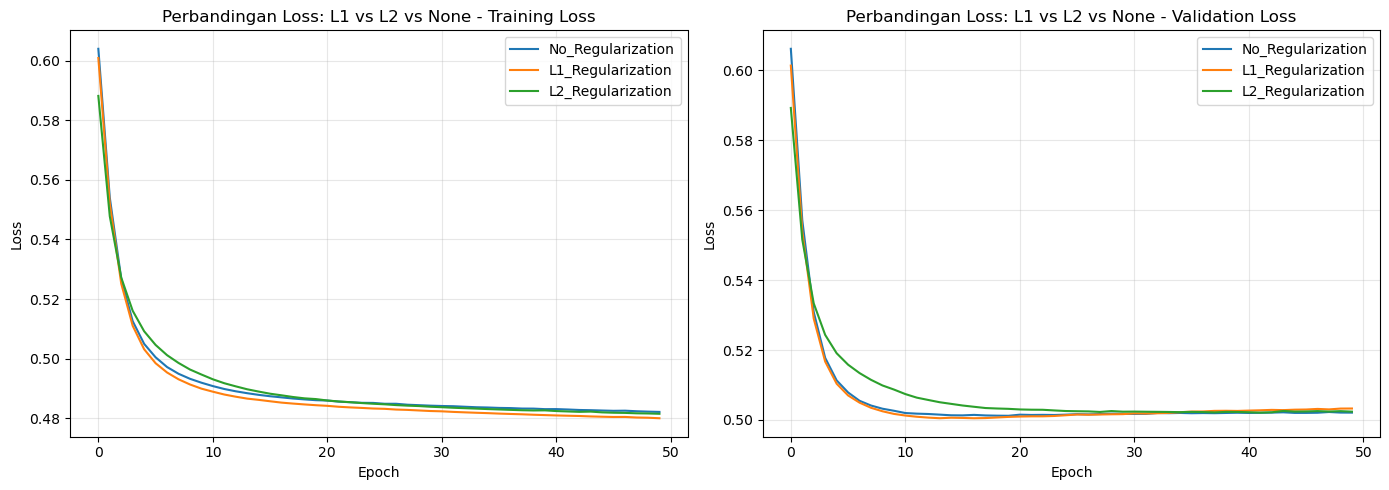

Analisis Distribusi Bobot dan Gradien (Layer 1):


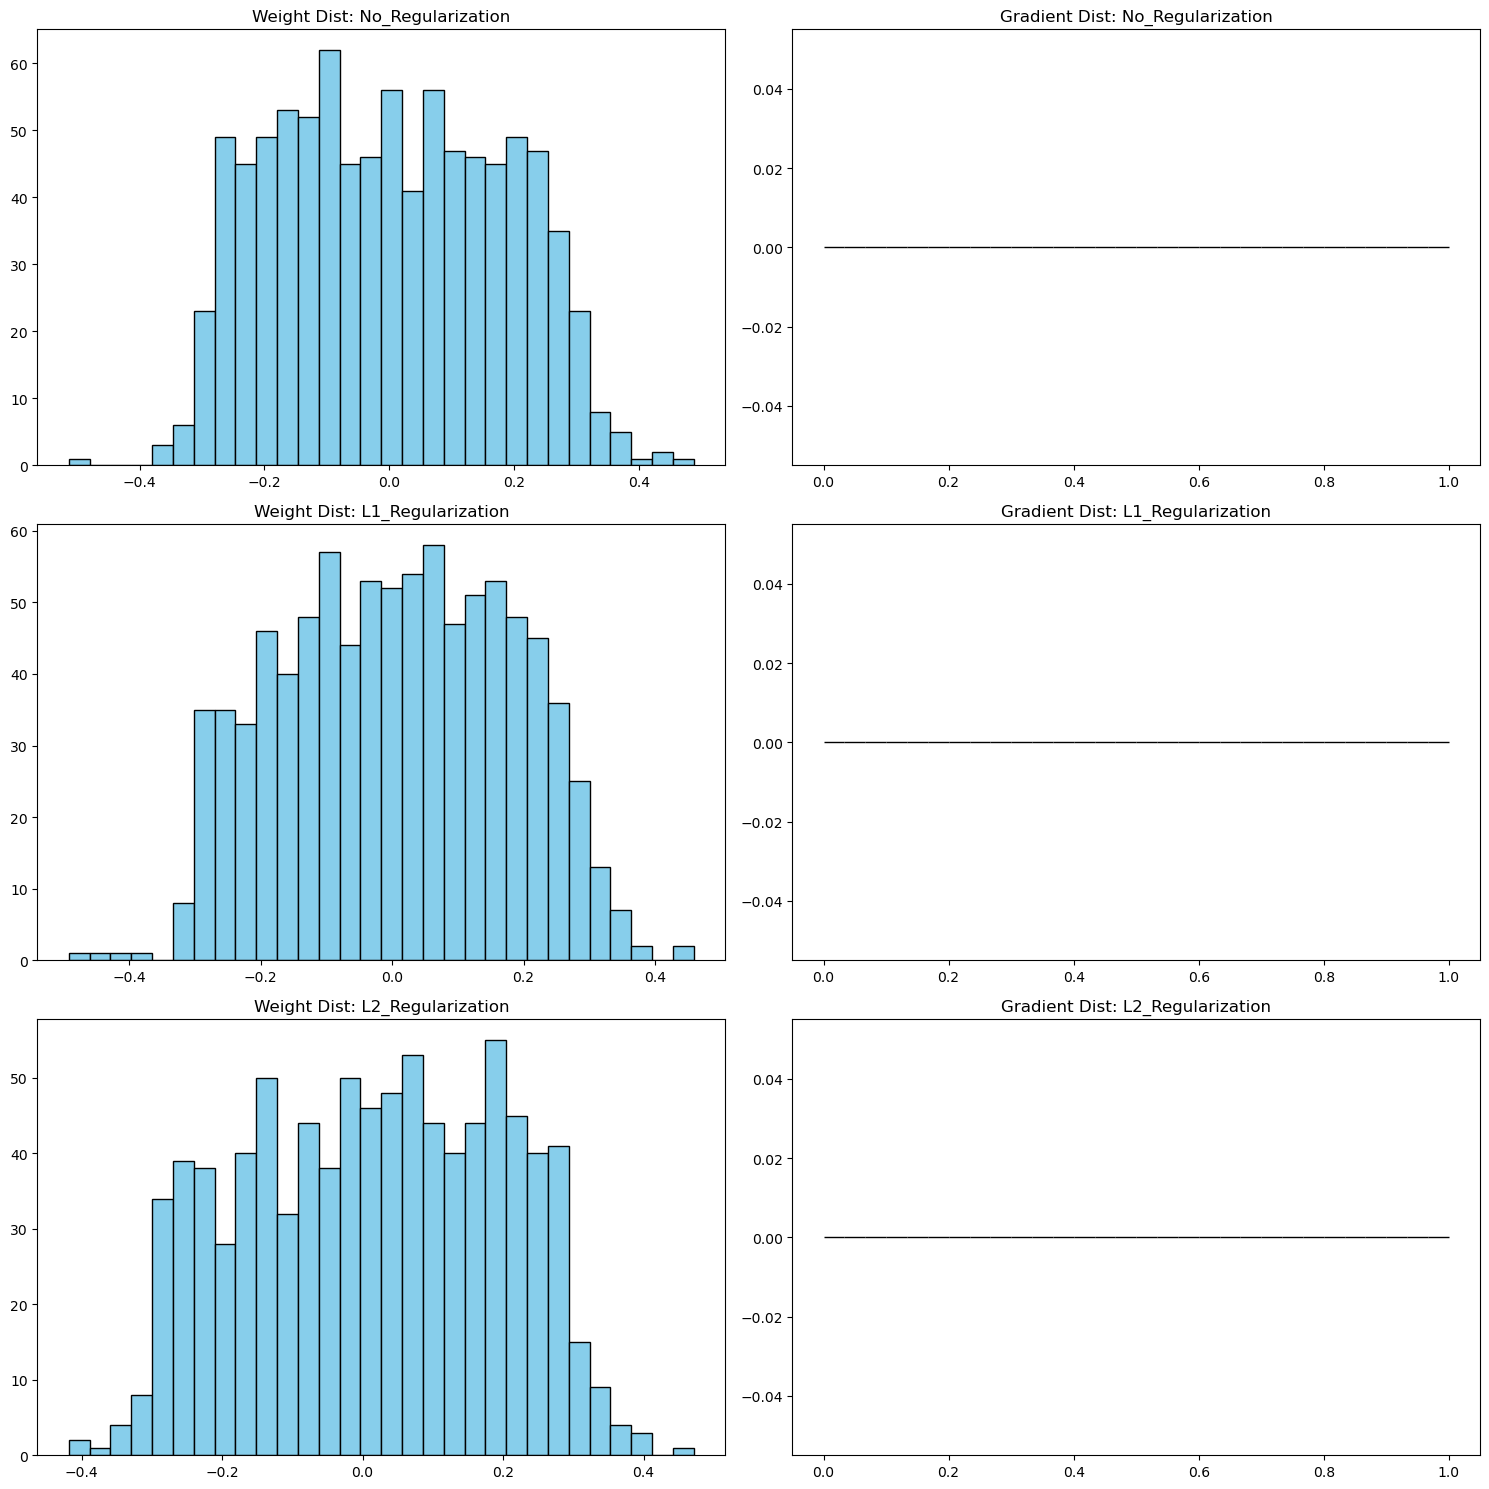

In [200]:
import matplotlib.pyplot as plt
import pandas as pd

reg_configs = [
    {"name": "No_Regularization", "l1": 0.0, "l2": 0.0},
    {"name": "L1_Regularization", "l1": 0.01, "l2": 0.0},
    {"name": "L2_Regularization", "l1": 0.0, "l2": 0.01}
]

reg_results = {}

for config in reg_configs:
    name = config["name"]
    model = build_network([X_train.shape[1], 32, 1], activations=[ReLU(), Sigmoid()])
    reg_results[name] = run_experiment(
        name, 
        model, 
        epochs=50, 
        lr=0.01, 
        l1_lambda=config["l1"], 
        l2_lambda=config["l2"]
    )
print("Tabel Perbandingan Metrik Regularisasi:")
display(results_to_dataframe(reg_results))
plot_history_collection(reg_results, "Perbandingan Loss: L1 vs L2 vs None")

def plot_distributions(results_dict):
    fig, axes = plt.subplots(len(results_dict), 2, figsize=(15, 5 * len(results_dict)))
    
    for i, (name, res) in enumerate(results_dict.items()):
        model = res["model"]
        weights = model.layers[0].weights.flatten()
        gradients = model.layers[0].d_weights.flatten() if hasattr(model.layers[0], 'd_weights') else []

        axes[i, 0].hist(weights, bins=30, color='skyblue', edgecolor='black')
        axes[i, 0].set_title(f"Weight Dist: {name}")
        
        axes[i, 1].hist(gradients, bins=30, color='salmon', edgecolor='black')
        axes[i, 1].set_title(f"Gradient Dist: {name}")
        
    plt.tight_layout()
    plt.show()

print("Analisis Distribusi Bobot dan Gradien (Layer 1):")
plot_distributions(reg_results)

In [201]:
from sklearn.neural_network import MLPClassifier

h_params = {
    'hidden_layer_sizes': (32,),
    'activation': 'relu', 
    'solver': 'sgd',      
    'learning_rate_init': 0.01,
    'max_iter': 50,
    'random_state': 42
}

mlp_sklearn = MLPClassifier(**h_params)
mlp_sklearn.fit(X_train, y_train)
y_pred_sklearn = mlp_sklearn.predict(X_test)

custom_model = build_network([X_train.shape[1], 32, 1], activations=[ReLU(), Sigmoid()])
res_custom = run_experiment("Custom_Model", custom_model, epochs=50, lr=0.01)
y_pred_custom = res_custom["pred"]

comparison_data = {
    "Metrik": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Custom FFNN": [
        res_custom["metrics"]["accuracy"],
        res_custom["metrics"]["precision"],
        res_custom["metrics"]["recall"],
        res_custom["metrics"]["f1"]
    ],
    "Sklearn MLP": [
        accuracy_score(y_test, y_pred_sklearn),
        precision_score(y_test, y_pred_sklearn),
        recall_score(y_test, y_pred_sklearn),
        f1_score(y_test, y_pred_sklearn)
    ]
}

print("Hasil Perbandingan Prediksi Akhir:")
display(pd.DataFrame(comparison_data))

c:\Users\62812\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1102: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\62812\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Running Custom_Model...
Hasil Perbandingan Prediksi Akhir:


,Metrik,Custom FFNN,Sklearn MLP
0,Accuracy,0.751000,0.750500
1,Precision,0.773712,0.778963
2,Recall,0.841592,0.830219
3,F1-Score,0.806226,0.803775
